In [2]:
from langchain_core.tools import tool
import httpx
from geopy.geocoders import Nominatim # uv add geopy
import json

def get_coordinates(city_name: str) -> tuple[float, float]:
    """도시 이름을 받아 위도와 경도를 반환합니다."""
    geolocator = Nominatim(user_agent="weather_app_langgraph")
    location = geolocator.geocode(city_name)
    if location:
        return location.latitude, location.longitude
    raise ValueError(f"좌표를 찾을 수 없습니다: {city_name}")

@tool
def get_weather(city_name: str) -> str:
    """도시 이름을 받아 해당 도시의 현재 날씨 정보를 반환합니다."""
    print(f"날씨 조회: {city_name}")
    latitude, longitude = get_coordinates(city_name)
    url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current_weather=true"
    response = httpx.get(url)
    response.raise_for_status()
    return json.dumps(response.json())

tools = [get_weather]

In [ ]:
get_coordinates("부산")

(35.1799528, 129.0752365)

In [4]:
tools[0].invoke({"city_name": "부산"})

날씨 조회: 부산


'{"latitude": 35.2, "longitude": 129.0625, "generationtime_ms": 0.05269050598144531, "utc_offset_seconds": 0, "timezone": "GMT", "timezone_abbreviation": "GMT", "elevation": 26.0, "current_weather_units": {"time": "iso8601", "interval": "seconds", "temperature": "\\u00b0C", "windspeed": "km/h", "winddirection": "\\u00b0", "is_day": "", "weathercode": "wmo code"}, "current_weather": {"time": "2026-06-13T08:45", "interval": 900, "temperature": 25.2, "windspeed": 6.1, "winddirection": 220, "is_day": 1, "weathercode": 0}}'

In [5]:
from langgraph.prebuilt import ToolNode # 에이전트와 도구 간의 인터페이스 역할을 하며, 언어 모델의 지시에 따라 실제 도구 실행을 담당하는 핵심적인 중간 다리
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv
load_dotenv()

# * 기상 전문가 서브 그래프 생성
def create_weather_agent():
    """날씨 관련 질문을 처리하는 전문가 서브그래프를 생성합니다."""
    model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite").bind_tools(tools)
    tool_node = ToolNode([get_weather])

    def call_model(state: MessagesState):
        return {"messages": [model.invoke(state["messages"])]}

    graph_builder = StateGraph(MessagesState)
    graph_builder.add_node("call_model", call_model)
    graph_builder.add_node("tool_node", tool_node)

    graph_builder.add_edge(START, "call_model")
    graph_builder.add_conditional_edges(
        "call_model",
        lambda s: "tool_node" if s["messages"][-1].tool_calls else END,
        {"tool_node": "tool_node", END: END},
    )
    graph_builder.add_edge("tool_node", "call_model")
    return graph_builder.compile()

In [6]:
from typing import Literal

# * 라우터 생성
def router(state: MessagesState) -> Literal["weather_expert", "general_agent"]:
    query = state["messages"][-1].content.lower()
    if "날씨" in query or "기온" in query:
        print("라우팅 결정: 기상 전문가에게 위임")
        return "weather_expert"
    print("라우팅 결정: 일반 에이전트가 처리")
    return "general_agent"

In [7]:
# * 메인 그래프 생성
def create_main_agent(weather_subgraph):
    """질문을 라우팅하고 처리하는 메인 에이전트 그래프를 생성합니다."""
    main_model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite") # 모델을 다르게 사용 가능

    graph_builder = StateGraph(MessagesState)
    graph_builder.add_node(
        "general_agent", lambda s: {"messages": [main_model.invoke(s["messages"])]}
    )
    graph_builder.add_node("weather_expert", weather_subgraph)
    graph_builder.add_conditional_edges(
        START,
        router,
        {
            "weather_expert": "weather_expert",
            "general_agent": "general_agent",
        },
    )
    graph_builder.add_edge("general_agent", END)
    graph_builder.add_edge("weather_expert", END)
    return graph_builder.compile()

In [8]:
print("=== LangGraph 서브그래프 예제 (기상 전문가) ===\n")
weather_agent = create_weather_agent()
main_agent = create_main_agent(weather_agent)

=== LangGraph 서브그래프 예제 (기상 전문가) ===



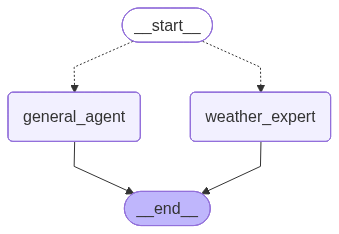

In [9]:
main_agent

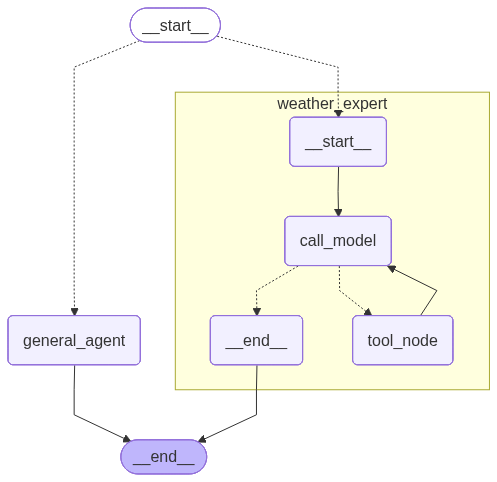

In [10]:
from IPython.display import Image

Image(main_agent.get_graph(xray=True).draw_mermaid_png())

In [11]:
from langchain_core.messages import HumanMessage

query = "부산 날씨 어때?"
result = main_agent.invoke({"messages": [HumanMessage(content=query)]})

result

라우팅 결정: 기상 전문가에게 위임
날씨 조회: 부산


{'messages': [HumanMessage(content='부산 날씨 어때?', additional_kwargs={}, response_metadata={}, id='5197e2cb-28bd-44fc-981b-aa54e058c2c2'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city_name": "\\ubd80\\uc0b0"}'}, '__gemini_function_call_thought_signatures__': {'MYbaNtkl': 'EjQKMgEMOdbHzxoo+sT+vBvqwUuxnljg00gc0z7NpmFEy6iuyFArs11cHNopP2FSnLe6z54N'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ec02e-97dc-7181-941f-0a2ea15dd185-0', tool_calls=[{'name': 'get_weather', 'args': {'city_name': '부산'}, 'id': 'MYbaNtkl', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 62, 'output_tokens': 18, 'total_tokens': 80, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='{"latitude": 35.2, "longitude": 129.0625, "generationtime_ms": 0.0883340835571289, "utc_offset_seconds": 0, "timezone": "GMT", 

In [12]:
from langchain_core.messages import HumanMessage

query = "랭그래프에 대해 핵심만 간단히 설명해줘."
result = main_agent.invoke({"messages": [HumanMessage(content=query)]})

result

라우팅 결정: 일반 에이전트가 처리


{'messages': [HumanMessage(content='랭그래프에 대해 핵심만 간단히 설명해줘.', additional_kwargs={}, response_metadata={}, id='e4019e38-f729-48f2-b9f1-668053839229'),
  AIMessage(content=[{'type': 'text', 'text': '**랭그래프(LangGraph)**를 한 문장으로 정의하면 **"LLM 애플리케이션을 위한 순환(Cyclic) 그래프 기반의 상태 유지 프레임워크"**입니다.\n\n핵심 요약은 다음과 같습니다.\n\n### 1. 왜 필요한가? (기존 랭체인과의 차이)\n* **기존 랭체인(LangChain)의 한계:** 주로 선형적(A→B→C)인 흐름에 최적화되어 있습니다.\n* **랭그래프의 해결책:** 루프(Loop)를 구현할 수 있습니다. 즉, **"답이 나올 때까지 다시 질문하기"**나 **"조건에 따라 이전 단계로 돌아가기"** 같은 복잡한 에이전트 워크플로우를 만들 수 있습니다.\n\n### 2. 3가지 핵심 개념\n1. **State (상태):** 그래프 안에서 공유되는 메모리입니다. 현재 진행 상황, 대화 내용, 중간 결과물 등을 저장하고 관리합니다.\n2. **Nodes (노드):** 특정 작업을 수행하는 함수(LLM 호출, 도구 사용 등)입니다.\n3. **Edges (엣지):** 노드 간의 이동 경로입니다. "어떤 조건일 때 어디로 갈지"를 결정합니다.\n\n### 3. 가장 큰 장점\n* **제어 가능성(Control):** 모델이 알아서 판단하는 것이 아니라, 개발자가 명확한 규칙(그래프)을 설정하여 에이전트의 행동을 정교하게 제어할 수 있습니다.\n* **지속성(Persistence):** 대화 중간에 상태를 저장하거나, 사람이 중간에 개입(Human-in-the-loop)하여 결과를 수정하고 다시 진행하는 기능을 쉽게 구현할 수 있습니다.\n\n**결론적으로:** 랭그래프는 **"단순한 챗봇을 넘어, 복잡